<a href="https://colab.research.google.com/github/aerau05/ml_assignments/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1.
1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty term that grows with the size of the model parameters discourages the model from assigning large weights to any single feature. Intuitively, this prevents the model from “overreacting” to noise in the training data. Instead of just minimizing error, the model is also encouraged to stay simple (i.e., with smaller coefficients), which tends to improve generalization to new data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization introduces bias by constraining the model (shrinking coefficients), but it reduces variance by making the model less sensitive to fluctuations in the training data. By tuning the strength of the penalty, we can move along the bias-variance trade-off: small penalties → low bias, high variance; large penalties → higher bias, lower variance. The goal is to find a balance that minimizes overall prediction error.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge regression uses an L2 penalty (squared coefficients), while LASSO uses an L1 penalty (absolute values of coefficients). Ridge shrinks coefficients toward zero but rarely makes them exactly zero, so it keeps all features in the model. LASSO, on the other hand, can drive some coefficients exactly to zero, effectively performing feature selection. As a result, Ridge is often preferred when many features contribute a little, while LASSO is useful when only a subset of features are important.

4. How do we typically scale variables for use in regularized regression? Why?

We typically standardize variables (subtract the mean and divide by the standard deviation) before applying regularization. This ensures that all features are on the same scale, so the penalty treats them fairly. Without scaling, variables with larger magnitudes could dominate the penalty and distort the model.

5. How is the penalty α typically selected?

The penalty parameter α is typically chosen using cross-validation. We train models across a range of α values and select the one that minimizes validation error. This ensures the chosen level of regularization generalizes well to unseen data.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

No, we typically evaluate cross-validated MSE using only the prediction error (without the penalty term). The goal is to measure how well the model predicts new data, not how well it optimizes the training objective. The penalty is used during training to shape the model, but performance is judged based on predictive accuracy alone.

In [1]:
! git clone https://github.com/aerau05/scratchpad
%cd scratchpad
!ls
%run get_data.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Cloning into 'scratchpad'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 27 (delta 4), reused 4 (delta 4), pack-reused 18 (from 1)
Receiving objects: 100% (27/27), 44.09 KiB | 1.84 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/scratchpad
'ds3001(1_20).ipynb'   get_data.py   nb_2026_01_05.ipynb   README.md
Download complete
Extracting data files...
Data extracted


In [9]:
## Question 2.

# 2.1
import pandas as pd
import numpy as np

df = pd.read_csv("/content/scratchpad/data/cars_hw.csv")

# Create Age
current_year = 2026
df["Age"] = current_year - df["Make_Year"]
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

X = df[["Mileage_Run", "Age"]]
y = df["Price"]   # adjust if target column differs

# (a) Polynomial expansion (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# (b) Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# 2.2
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_scaled, y)

coeffs = pd.Series(linreg.coef_, index=feature_names)
print(coeffs)
coeffs["Mileage_Run Age"]

Mileage_Run          9.117748e+05
Age                 -2.481722e+05
Mileage_Run^2       -2.072926e+05
Mileage_Run Age     -1.671212e+06
Age^2                3.505507e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    3.388195e+05
Mileage_Run Age^2    7.167816e+05
Age^3               -2.100379e+05
dtype: float64


np.float64(-1671212.3563918793)

2.2) The sign for the interaction between Mileage_Run and Age is negative.

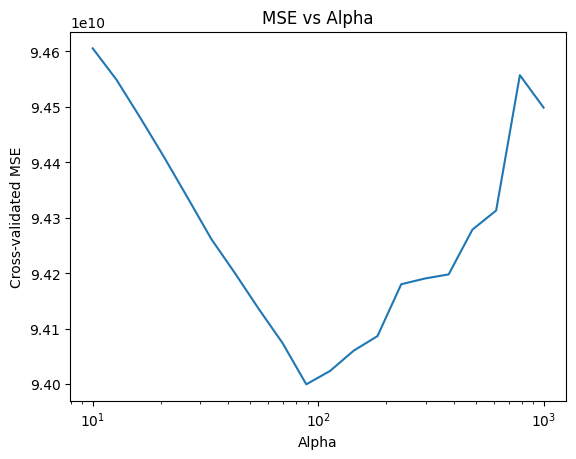

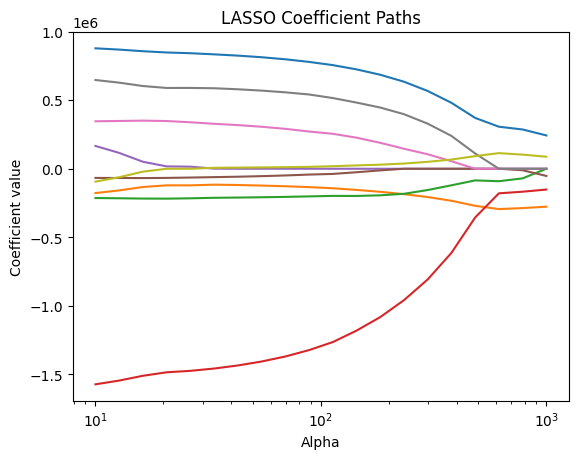

Selected features:
 Mileage_Run          7.790762e+05
Age                 -1.339534e+05
Mileage_Run^2       -2.015634e+05
Mileage_Run Age     -1.322419e+06
Mileage_Run^3       -4.240952e+04
Mileage_Run^2 Age    2.715062e+05
Mileage_Run Age^2    5.415432e+05
Age^3                1.374220e+04
dtype: float64
Proportion zero: 0.1111111111111111
                         Linear         LASSO
Mileage_Run        9.117748e+05  7.790762e+05
Age               -2.481722e+05 -1.339534e+05
Mileage_Run^2     -2.072926e+05 -2.015634e+05
Mileage_Run Age   -1.671212e+06 -1.322419e+06
Age^2              3.505507e+05  0.000000e+00
Mileage_Run^3     -6.514490e+04 -4.240952e+04
Mileage_Run^2 Age  3.388195e+05  2.715062e+05
Mileage_Run Age^2  7.167816e+05  5.415432e+05
Age^3             -2.100379e+05  1.374220e+04


In [19]:
# 2.3
from sklearn.linear_model import LassoCV

alphas = np.logspace(1, 3, 20)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled, y)

#2.4
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

#2.5
from sklearn.linear_model import Lasso

coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

#2.6
lasso_coeffs = pd.Series(lasso_cv.coef_, index=feature_names)

selected = lasso_coeffs[lasso_coeffs != 0]
zeroed = lasso_coeffs[lasso_coeffs == 0]

print("Selected features:\n", selected)
print("Proportion zero:", len(zeroed) / len(lasso_coeffs))

#2.7
comparison = pd.DataFrame({
    "Linear": linreg.coef_,
    "LASSO": lasso_cv.coef_
}, index=feature_names)

print(comparison)

2.6) The LASSO model selected all features except Age^2, which was set exactly to zero. The selected features were Mileage_Run, Age, Mileage_Run^2, Mileage_Run x Age, Mileage_Run^3, Mileage_Run^2 x Age, Mileage_Run x Age^2, and Age^3. Out of 9 total features, 1 coefficient was set to zero, meaning 11.1% of features were eliminated.

2.7) Overall, most coefficients decreased in magnitude when moving from linear regression to LASSO. This is expected because LASSO applies a L1 penalty that shrinks coefficients toward zero to reduce model complexity. No coefficients increased in magnitude, all non-zero coefficients became samller under LASSO. One coefficient, Age^2, was reduced entirely to zero, indicating it was not important for prediction acter regularization. Nost coefficients remained the same sign, meaning their directional relationship with the response variable stayed consistent. However, the coefficient for AGE^3 changed sign (from negative in linear regression to positive in LASSO), suggesting instability.  

In [21]:
# Question 3.

#3.1
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("/content/scratchpad/data/heart_failure_clinical_records_dataset.csv")

# Continuous variables
X_cont = df[["age", "ejection_fraction", "serum_creatinine"]]

# Polynomial (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly.fit_transform(X_cont)
cont_features = poly.get_feature_names_out(X_cont.columns)

# Scale
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

# Categorical (binary) variables
X_cat = df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]

# Interaction-only for categorical
poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)
cat_features = poly_cat.get_feature_names_out(X_cat.columns)

# Combine
X = np.hstack([X_cont_scaled, X_cat_inter])
feature_names = list(cont_features) + list(cat_features)

y = df["DEATH_EVENT"]

#3.2
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X, y)

lin_coeffs = pd.Series(linreg.coef_, index=feature_names)
print(lin_coeffs.sort_values())

age^2                                    -3.678654
serum_creatinine^2                       -2.647041
ejection_fraction                        -2.192494
age ejection_fraction serum_creatinine   -1.577665
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction^3                      -1.250341
serum_creatinine                         -0.853588
age^2 serum_creatinine                   -0.697522
age ejection_fraction                    -0.600918
smoking                                  -0.102687
age ejection_fraction^2                  -0.081206
diabetes                                 -0.070705
anaemia high_blood_pressure              -0.027251
high_blood_pressure                      -0.007934
anaemia                                   0.008093
anaemia diabetes                          0.026159
anaemia smoking                           0.064908
serum_creatinine^3                        0.072156
high_blood_pressure smoking               0.101455
diabetes high_blood_pressure   

3.2) Several coefficients show counterintuitive sign patterns, such as age having a positive coefficient while age^2 is negative, and ejection_fraction being negative while ejection_fraction^2 is positive. This happens because the model includes many correlated polynomial and interaction terms, which distribute effects across variables and can cause individual coefficients to appear inconsistent. Rather than interpreting coefficients in isolation, these highe-order terms work together to capture nonlinear relationships, so the overall model can still reflect realistic patterns even if some individual signs seem contradictory.

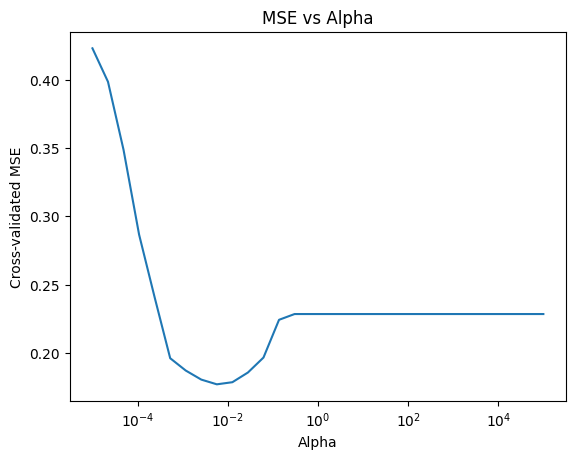

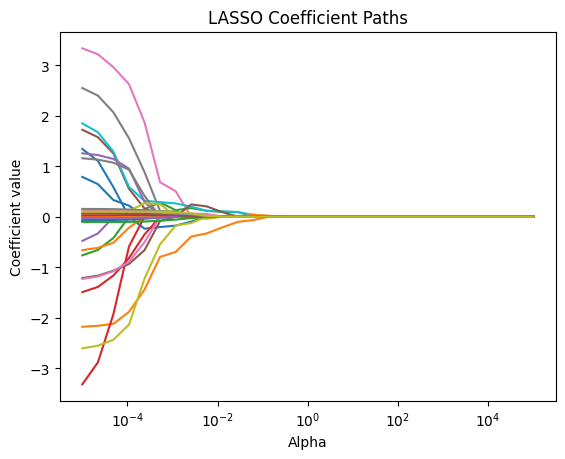

Selected features:
 ejection_fraction                      -0.329656
serum_creatinine                        0.116875
age^3                                   0.117992
ejection_fraction^3                     0.204822
ejection_fraction^2 serum_creatinine    0.032801
serum_creatinine^3                     -0.043266
anaemia                                 0.014178
diabetes                                0.000607
high_blood_pressure                     0.013608
diabetes high_blood_pressure            0.053968
diabetes smoking                        0.003466
high_blood_pressure smoking             0.017805
dtype: float64
Proportion zero: 0.5862068965517241
                                          Linear     LASSO
age                                     1.539156 -0.000000
ejection_fraction                      -2.192494 -0.329656
serum_creatinine                       -0.853588  0.116875
age^2                                  -3.678654  0.000000
age ejection_fraction                  -0.6009

In [24]:
#3.3
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X, y)

lasso_coeffs = pd.Series(lasso_cv.coef_, index=feature_names)

#3.4
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Cross-validated MSE")
plt.title("MSE vs Alpha")
plt.show()

#3.5
from sklearn.linear_model import Lasso

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

#3.6
selected = lasso_coeffs[lasso_coeffs != 0]
zeroed = lasso_coeffs[lasso_coeffs == 0]

prop_zero = len(zeroed) / len(lasso_coeffs)

print("Selected features:\n", selected)
print("Proportion zero:", prop_zero)

comparison = pd.DataFrame({
    "Linear": linreg.coef_,
    "LASSO": lasso_cv.coef_
}, index=feature_names)

print(comparison)

3.6) The LASSO model selected a relatively small subset of features, keeping 12 predictors and setting 58.6% of coefficients to zero, indicating substantial feature selection. Compared to linear regression, most coefficients decreased in magnitude, and many higher-order and interaction terms were eliminated entirely. Some coefficients also changed sign, such as serum_creatine and ejection_fraction^3, reflectinginstability in the unregularized model due to multicollinearity. Overall, the LASSO model produces more reasonable and stable sign patterns by reducing variance, whereas the linear model, with many correlated polynomial terms, has higher variance and less interpretable coefficients. This demonstrates the bias-variance trade-off, where LASSO introduces some bias but improves generalization and interpretability.

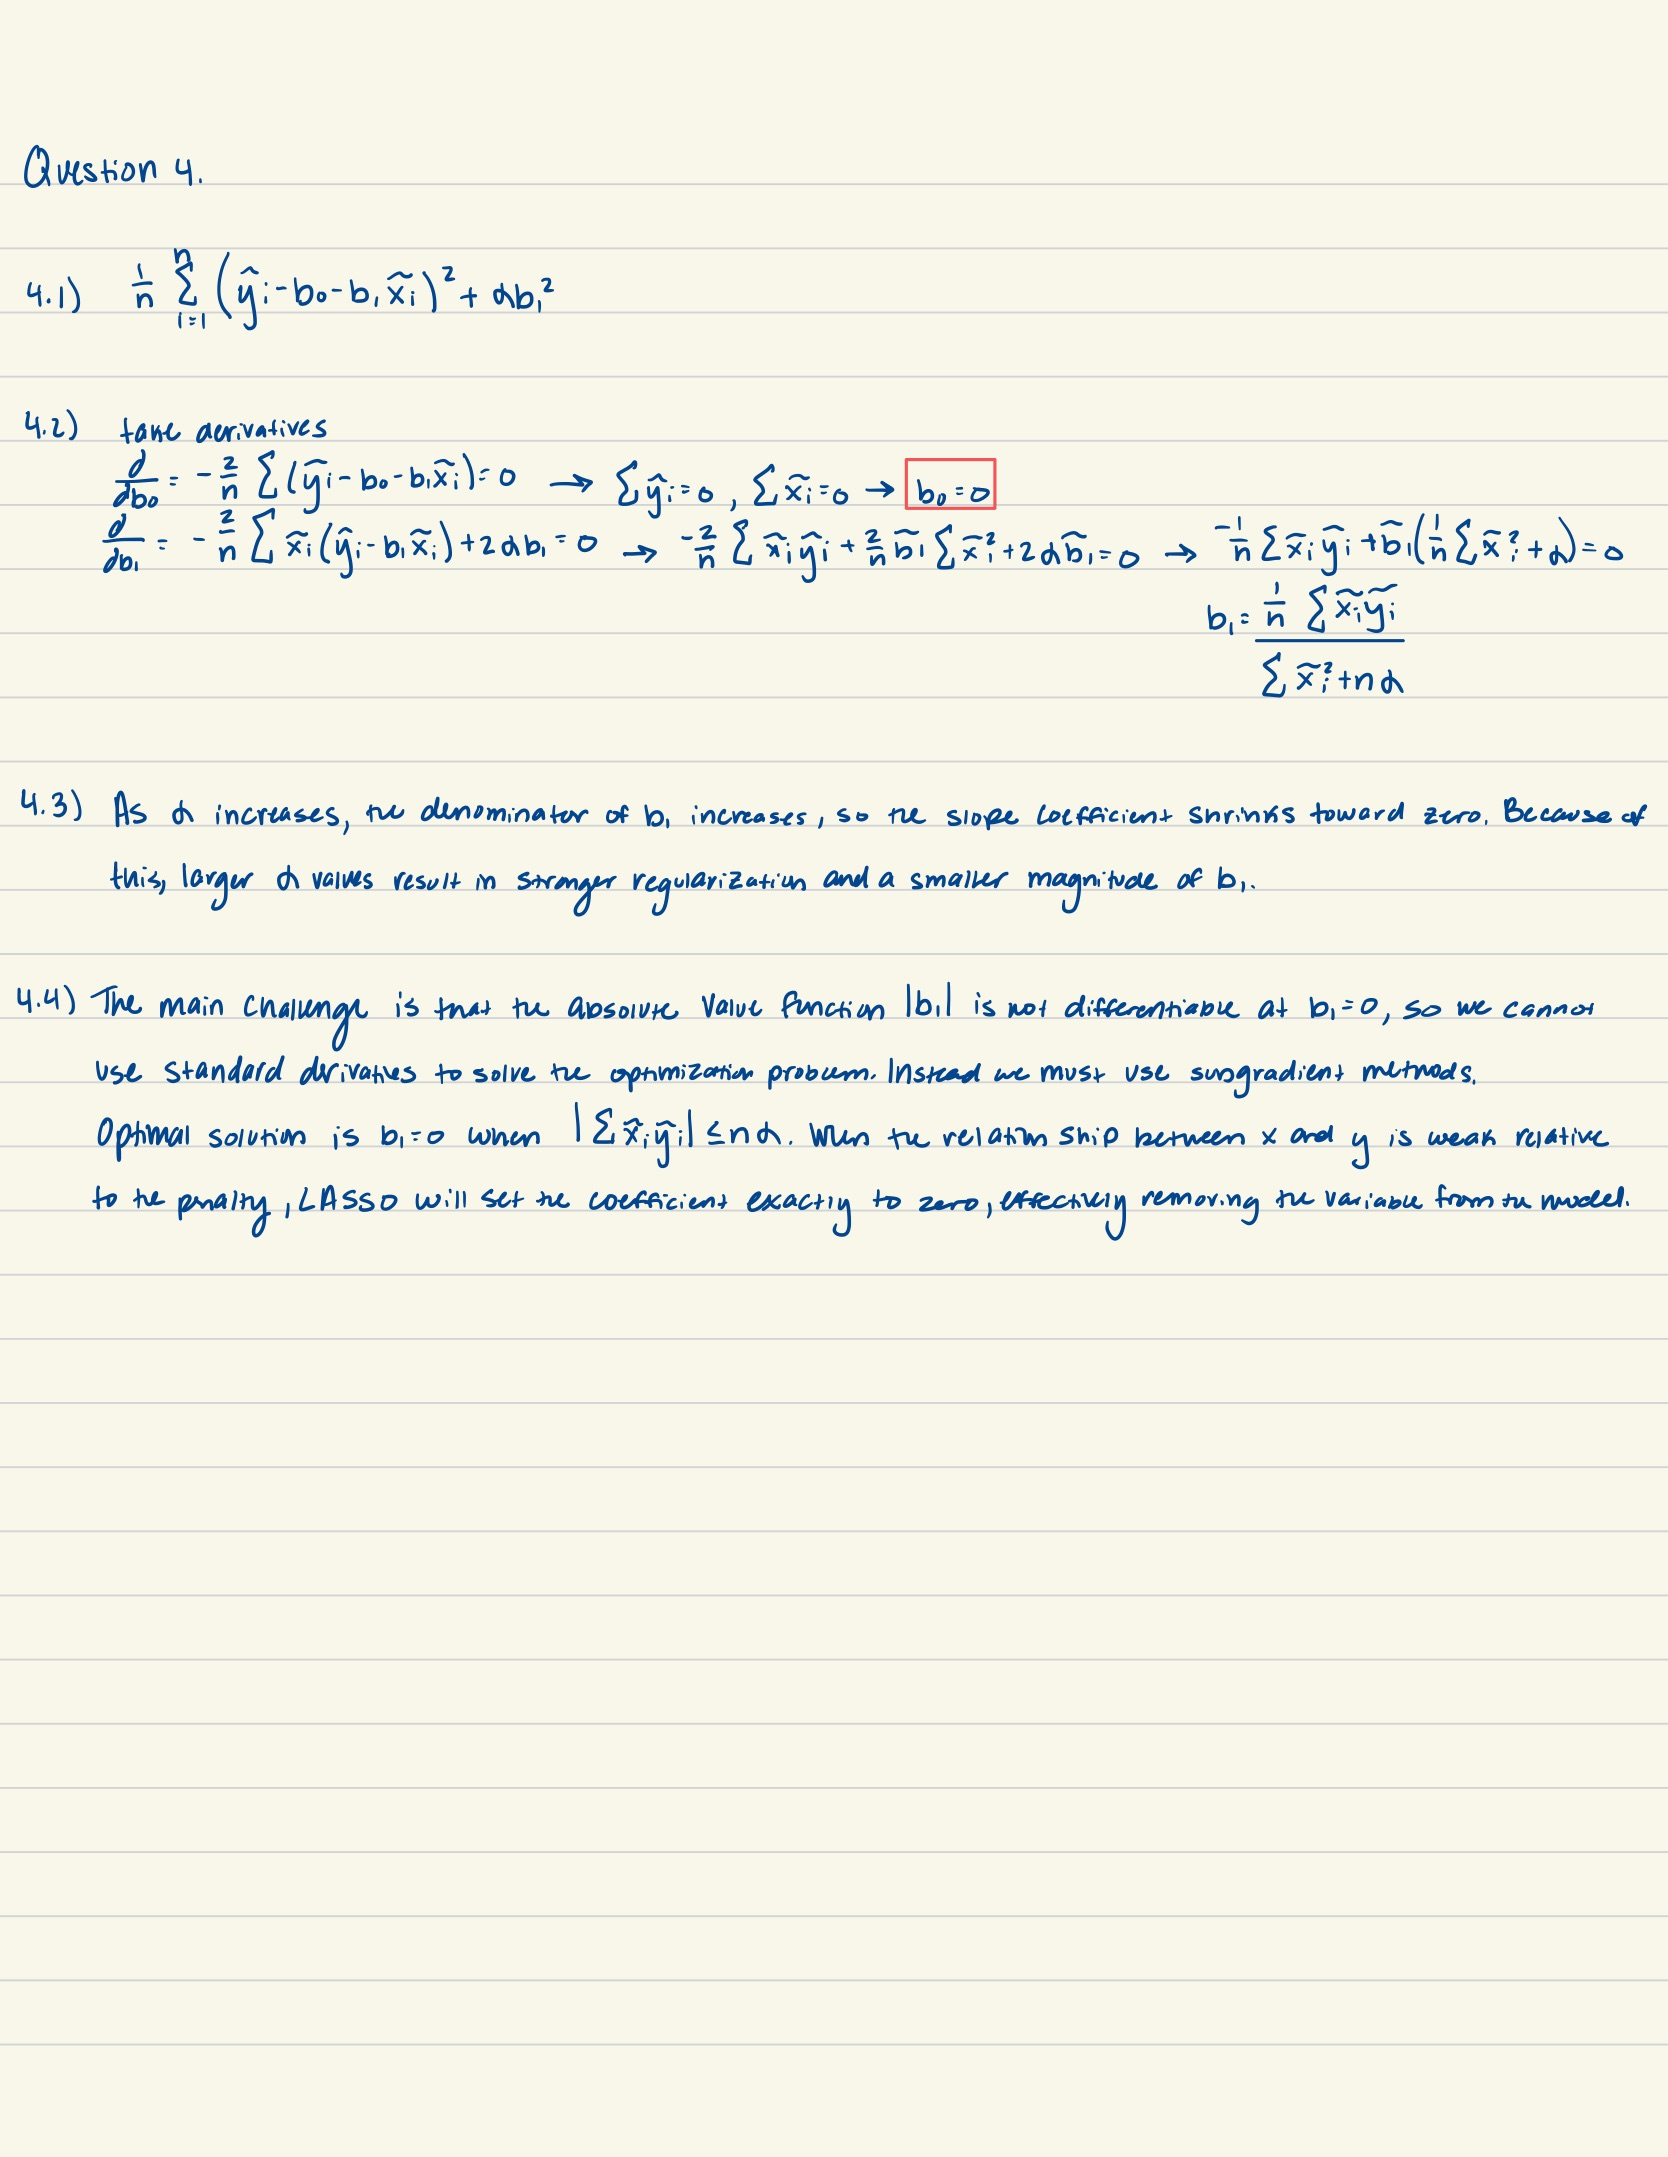